### NODS vs NEURON (Reproduce Figure 2)
[NO] reaction cascade characterized by instantaneous Ca2+ events, following spikes, causing a smooth build-up of NO.
 
Time and space profile of the NO signal, produced by a single source stimulated with different frequencies (color-coded by darkening the shade of green): single spike, 10 Hz, 20 Hz, 50 Hz, 100 Hz, 300 Hz, 500 Hz. All stimuli have been delivered at ti = 0 ms and last for 200 ms.

In [18]:
import numpy as np
import math as m
from numpy import arange as arange
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D


dt     = 1 # size of a time step [ms]
t_sim  = 1000 # simulation time [ms] 
time = arange(0,t_sim,dt)
folder_path = '/home/csartor1/code/nearlab_repo/NODS/data/Neuron_comparison/'
vm = np.loadtxt(folder_path+'grc_vm.txt')
Cai = np.loadtxt(folder_path+'grc_cai.txt')
CAM2C = np.loadtxt(folder_path+'grc_CAM2C.txt')
NO = np.loadtxt(folder_path+'grc_no.txt')

### Load NEURON simulation

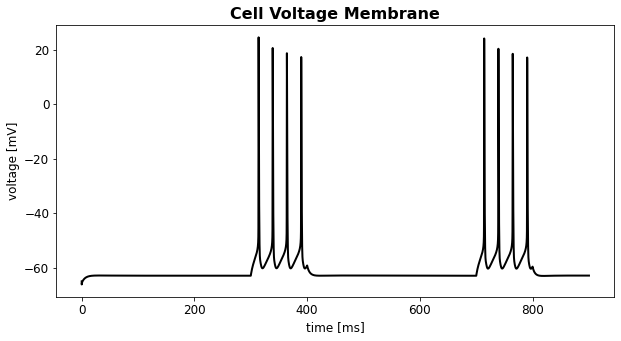

In [19]:
# Plotting cell voltage membrane
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(10,5))
plt.plot(vm[:,0],vm[:,1], 'k', linewidth=2)
plt.xlabel('time [ms]')
#plt.xlim(right = 1050)
plt.ylabel('voltage [mV]')
plt.title('Cell Voltage Membrane', fontsize=16,fontweight ='bold')
plt.savefig('vm_neuron.png')
plt.show()

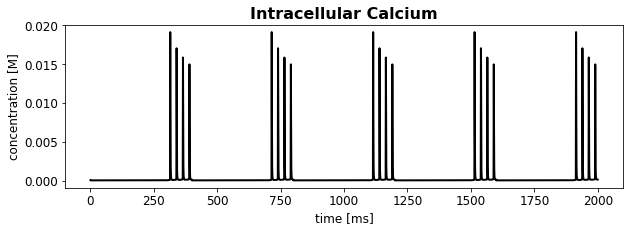

In [20]:
# Plotting intracellular calcium concentration
ca_conc = []
ca_time = []
calcium = Cai[Cai[:,0]<=400]

for i in range(5):
    
    ca_time.append(calcium[:,0]+400*i)
    ca_conc.append(calcium[:,1])

ca_time = np.concatenate(ca_time)
ca_conc = np.concatenate(ca_conc)

plt.figure(figsize=(10,3))

plt.plot(ca_time,ca_conc, 'k', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('Intracellular Calcium', fontsize=16,fontweight ='bold')
plt.show()

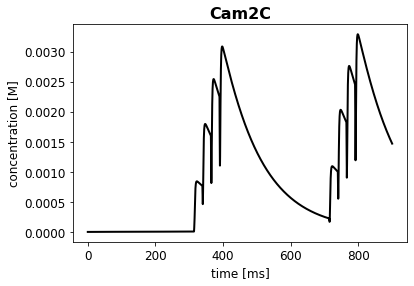

In [21]:
# Plotting CAM2C complex concentration
plt.plot(CAM2C[:,0], CAM2C[:,1], 'k', linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('Cam2C', fontsize=16,fontweight ='bold')
plt.show()

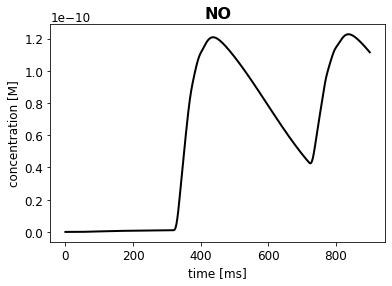

In [22]:
# Plotting NO concentration
plt.plot(NO[:,0],NO[:,1],  'k',linewidth=2)
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('NO', fontsize=16,fontweight ='bold')
plt.show()

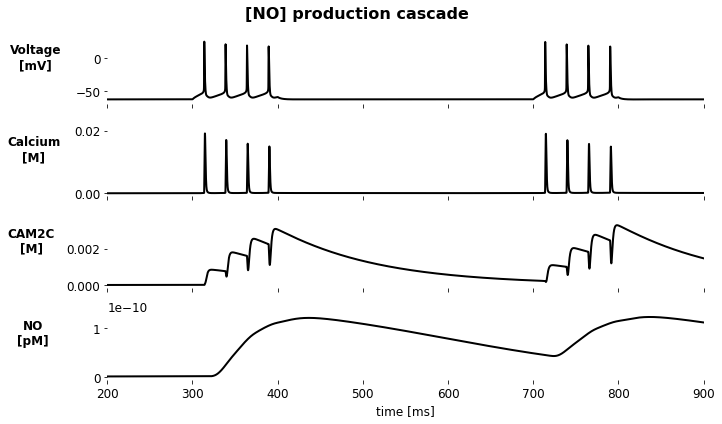

In [9]:
plt.rcParams.update({'font.size': 12},)
fig, axs = plt.subplots(4,1,figsize=(10,6),sharex=True)

axs[0].plot(vm[:,0],vm[:,1], 'k', linewidth=2)
plt.xlabel('time [ms]')
#plt.xlim(right = 1800)
axs[0].set_ylabel('Voltage\n[mV]', rotation=0, labelpad = 40, fontweight ='bold')
plt.suptitle('[NO] production cascade', fontsize=16, fontweight ='bold')
plt.tight_layout()
axs[0].set_frame_on(False)
#axs[0].spines['top'].set_visible(False)
#axs[0].spines['right'].set_visible(False)

axs[1].plot(Cai[:,0],Cai[:,1], 'k', linewidth=2)
axs[1].set_ylabel('Calcium\n[M]', rotation=0, labelpad = 40, fontweight ='bold')
axs[1].set_frame_on(False)
axs[2].plot(CAM2C[:,0],CAM2C[:,1], 'k', linewidth=2)
axs[2].set_ylabel('CAM2C\n[M]', rotation=0, labelpad = 35, fontweight ='bold')
axs[2].set_frame_on(False)
axs[3].plot(NO[:,0],NO[:,1], 'k', linewidth=2)
axs[3].set_ylabel('NO\n[pM]', rotation=0, labelpad = 60, fontweight ='bold')
axs[3].set_frame_on(False)
axs[3].set_xlim(200,900)
plt.show()

In [52]:
import numpy as np
import math as m
from numpy import arange as arange
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D


#production function
tau = -150
tauNOS1 = 200
tauNOS2 = 25
A = 1.35e-9

dt     = 1 # size of a time step [ms]
t_sim  = 1000 # simulation time [ms] 
time = arange(0,t_sim,dt)

spike = np.zeros((len(time)))
spike[315]=1
spike[340]=1
spike[365]=1
spike[390]=1
spike[715]=1
spike[740]=1
spike[765]=1
spike[790]=1

spike_vm = np.ones((len(time)))*-65
spike_vm[315]=1
spike_vm[340]=1
spike_vm[365]=1
spike_vm[390]=1
spike_vm[715]=1
spike_vm[740]=1
spike_vm[765]=1
spike_vm[790]=1

Ca = np.zeros((len(time)))
nNOS = np.zeros((len(time)))

for i in range(1,t_sim,1):
    #production equations
    Ca[i] = Ca[i-1] + (((Ca[i-1]/tau) + spike[i-1])*dt)
    nNOS[i] = nNOS[i-1]+((((1/tauNOS1)*((Ca[i-1])/((Ca[i-1])+1)))-(nNOS[i-1]/tauNOS2))*dt)

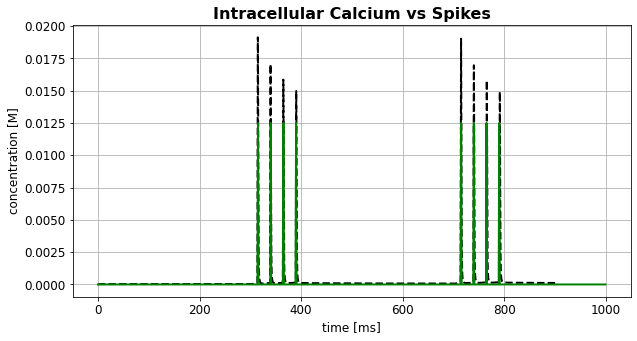

In [54]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(10,5))
plt.plot(Cai[:,0],Cai[:,1], '--k', linewidth=2, label = '[Ca2+] in NEURON')
plt.plot(spike*0.0125,'g',  linewidth=2, label = 'spikes in NEST')
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('Intracellular Calcium vs Spikes', fontsize=16,fontweight ='bold')
plt.grid(visible=True)
plt.savefig('ca_neuron.png')
plt.show()


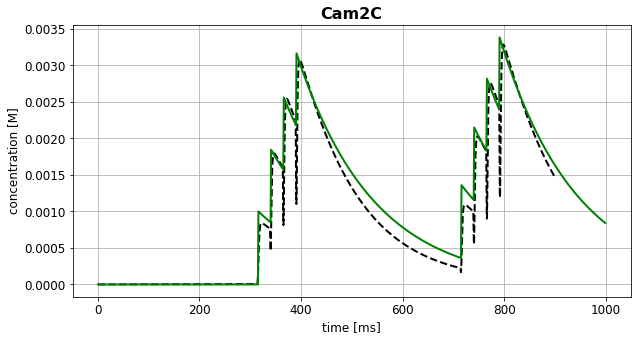

In [55]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(10,5))
plt.plot(CAM2C[:,0], CAM2C[:,1], '--k', linewidth=2, label = 'NEURON')
plt.plot(Ca*1e-3,'g',  linewidth=2, label = 'two eq. system')
plt.xlabel('time [ms]')
plt.ylabel('concentration [M]')
plt.title('Cam2C', fontsize=16,fontweight ='bold')
plt.grid(visible=True)
plt.savefig('Cam2c_neuron.png')
plt.show()

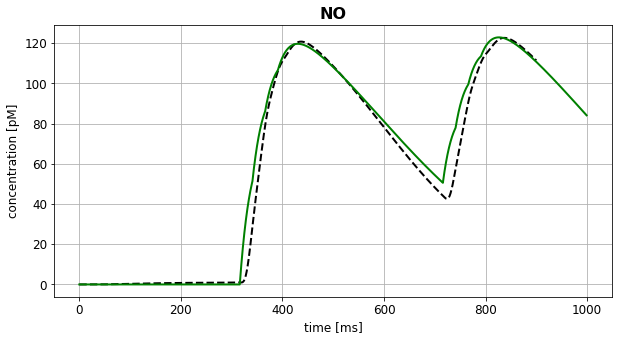

In [56]:

plt.figure(figsize=(10,5))
plt.plot(NO[:,0],NO[:,1]*10**(12), '--k' ,linewidth=2, label = 'NEURON')
plt.plot(nNOS*A*10**(12), 'g',linewidth=2, label = 'two eq. system')
plt.xlabel('time [ms]')
plt.ylabel('concentration [pM]')
plt.title('NO', fontsize=16,fontweight ='bold')
plt.grid(visible=True)
plt.savefig('NO_neuron.png')
plt.show()

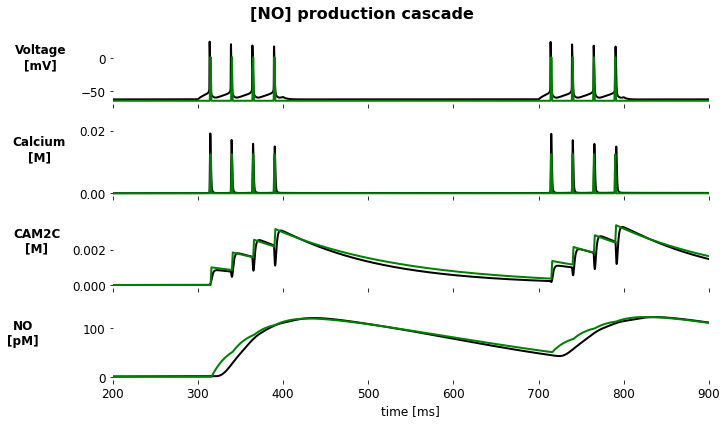

In [60]:
plt.rcParams.update({'font.size': 12},)
fig, axs = plt.subplots(4,1,figsize=(10,6),sharex=True)

axs[0].plot(vm[:,0],vm[:,1], 'k', linewidth=2)
axs[0].plot(spike_vm, 'g', linewidth=2, label = 'spikes in NEST')
plt.xlabel('time [ms]')
#plt.xlim(right = 1800)
axs[0].set_ylabel('Voltage\n[mV]', rotation=0, labelpad = 40, fontweight ='bold')
plt.suptitle('[NO] production cascade', fontsize=16, fontweight ='bold')
plt.tight_layout()
axs[0].set_frame_on(False)
#axs[0].spines['top'].set_visible(False)
#axs[0].spines['right'].set_visible(False)

axs[1].plot(Cai[:,0],Cai[:,1], 'k', linewidth=2)
axs[1].plot(spike*0.0125, 'g', linewidth=2, label = 'two eq. system')
axs[1].set_ylabel('Calcium\n[M]', rotation=0, labelpad = 40, fontweight ='bold')
axs[1].set_frame_on(False)
axs[2].plot(CAM2C[:,0],CAM2C[:,1], 'k', linewidth=2)
axs[2].plot(Ca*1e-3, 'g', linewidth=2, label = 'two eq. system')
axs[2].set_ylabel('CAM2C\n[M]', rotation=0, labelpad = 35, fontweight ='bold')
axs[2].set_frame_on(False)
axs[3].plot(NO[:,0],NO[:,1]*10**(12), 'k', linewidth=2)
axs[3].plot(nNOS*A*10**(12), 'g', linewidth=2, label = 'two eq. system')
axs[3].set_ylabel('NO\n[pM]', rotation=0, labelpad = 60, fontweight ='bold')
axs[3].set_frame_on(False)
axs[3].set_xlim(200,900)
plt.show()